# Core Task 1 - T2 Relaxometry QC (Python)

This notebook implements **core task 1** for `T2_MRI_coursework.pdf`:
- inspect acquisition/model-assumption violations before model fitting,
- quantify monotonicity and mono-exponential consistency,
- rank case-level risk and propose fitting-stage mitigations.


## 0) Environment and Setup

Expected environment:
- Python 3.11
- Required: `numpy`, `scipy`, `matplotlib`, `pandas`
- Optional: `nibabel` (if absent, code uses a fallback `.nii.gz` loader based on `gzip+struct`)

If needed in your current kernel, run:
```python
# %pip install numpy scipy matplotlib pandas nibabel
```


In [57]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'core_task1').exists() and (ROOT.parent / 'core_task1').exists():
    ROOT = ROOT.parent.resolve()

DATASET_ROOT = ROOT / 'cmbi_data' / 'cmbi_data'
GLOBAL_TES_PATH = ROOT / 'cmbi_data' / 'TEs.txt'
NUM_CASES = 10  # Set to None to analyze all discovered cases.
TARGET_CASE_IDS = ['Epicure96179', 'Epicure66734']  # e.g. ['Epicure11610', 'Epicure14416']; if set, overrides NUM_CASES.

CORE_DIR = ROOT / 'core_task1'
if str(CORE_DIR) not in sys.path:
    sys.path.insert(0, str(CORE_DIR))

from task1_qc import (
    DEFAULT_THRESHOLDS,
    discover_cases,
    load_case,
    audit_case,
    compute_global_decay_profile,
    sample_curves,
    compute_qc_metrics,
    make_case_report,
    summarize_case_reports,
    run_synthetic_sanity_checks,
    read_tes,
)

SEED = 7
THRESHOLDS = dict(DEFAULT_THRESHOLDS)
THRESHOLDS.update(
    {
        'mono_rel_inc_thresh': 0.05,
        'r2_poor_thresh': 0.95,
        'echo_z_thresh': 2.5,
    }
)

OUTPUT_DIR = ROOT / 'core_task1' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Repository root:', ROOT)
print('Dataset root:', DATASET_ROOT)
print('Global TEs path:', GLOBAL_TES_PATH)
print('Number of cases to analyze:', NUM_CASES if NUM_CASES is not None else 'all')
print('Target case IDs:', TARGET_CASE_IDS if TARGET_CASE_IDS else 'auto (use NUM_CASES)')
print('Output dir:', OUTPUT_DIR)
print('Thresholds:', THRESHOLDS)



Repository root: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework
Dataset root: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework\cmbi_data\cmbi_data
Global TEs path: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework\cmbi_data\TEs.txt
Number of cases to analyze: 10
Target case IDs: ['Epicure96179', 'Epicure66734']
Output dir: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework\core_task1\outputs
Thresholds: {'mono_rel_inc_thresh': 0.05, 'early_echo_fraction': 0.5, 'r2_poor_thresh': 0.95, 'echo_z_thresh': 2.5, 'max_voxels_for_r2': 5000, 'eps': 1e-06}


In [58]:
import importlib.util as iu

required = ['numpy', 'scipy', 'matplotlib', 'pandas']
optional = ['nibabel', 'seaborn']
rows = []
for module_name in required + optional:
    rows.append(
        {
            'module': module_name,
            'installed': bool(iu.find_spec(module_name)),
            'required': module_name in required,
        }
    )

deps_df = pd.DataFrame(rows)
display(deps_df)

missing_required = deps_df.query('required and not installed')
if not missing_required.empty:
    raise RuntimeError(f'Missing required dependencies: {missing_required.module.tolist()}')

if bool(iu.find_spec('nibabel')):
    print('nibabel detected: standard NIfTI loading path will be used.')
else:
    print('nibabel not detected: fallback gzip+struct NIfTI loader will be used.')


,module,installed,required
0,numpy,True,True
1,scipy,True,True
2,matplotlib,True,True
3,pandas,True,True
4,nibabel,True,False
5,seaborn,True,False


nibabel detected: standard NIfTI loading path will be used.


## 1) Data Audit

For each case we verify:
- shape consistency (`qt2_reg` 4D vs mask 3D),
- TE consistency (non-decreasing, duplicates),
- basic signal sanity.


In [59]:
cases = discover_cases(DATASET_ROOT)
if not cases:
    raise RuntimeError(f'No cases found under {DATASET_ROOT}')

if TARGET_CASE_IDS:
    case_by_id = {cp.case_id: cp for cp in cases}
    requested = [str(cid).strip() for cid in TARGET_CASE_IDS if str(cid).strip()]
    dedup_requested = list(dict.fromkeys(requested))
    missing = [cid for cid in dedup_requested if cid not in case_by_id]
    if missing:
        raise ValueError(
            f'Requested case IDs not found under {DATASET_ROOT}: {missing}. '
            f'Available examples: {[cp.case_id for cp in cases[:20]]}'
        )
    cases = [case_by_id[cid] for cid in dedup_requested]
elif NUM_CASES is not None:
    if int(NUM_CASES) <= 0:
        raise ValueError(f'NUM_CASES must be positive or None, got {NUM_CASES}')
    cases = cases[: int(NUM_CASES)]

if not GLOBAL_TES_PATH.exists():
    raise FileNotFoundError(f'Global TEs file not found: {GLOBAL_TES_PATH}')
global_tes = read_tes(GLOBAL_TES_PATH).astype(np.float64, copy=False)

print(f'Loaded {len(cases)} case(s) from {DATASET_ROOT}')
print('Selected case IDs:', [cp.case_id for cp in cases])
print('Using shared TEs:', GLOBAL_TES_PATH)

case_data = {}
audit_rows = []
for cp in cases:
    bundle = load_case(cp.case_dir, cp.case_id)
    if bundle['data'].shape[3] != global_tes.size:
        raise ValueError(
            f"TE length mismatch for {cp.case_id}: data has {bundle['data'].shape[3]} echoes, "
            f"but global TEs has {global_tes.size} values"
        )
    bundle['tes'] = global_tes.copy()
    case_data[cp.case_id] = bundle
    audit_rows.append(audit_case(bundle['data'], bundle['mask'], bundle['tes'], case_id=cp.case_id))

audit_df = pd.DataFrame(audit_rows).sort_values('case_id').reset_index(drop=True)
audit_df



Loaded 2 case(s) from C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework\cmbi_data\cmbi_data
Selected case IDs: ['Epicure96179', 'Epicure66734']
Using shared TEs: C:\Users\13822\Desktop\Machine Learning\COMP0118\group coursework\cmbi_data\TEs.txt


,case_id,shape_xyz_t,mask_shape_xyz,shape_match,time_match,te_count,te_non_decreasing,te_duplicate_count,te_min_step_ms,brain_voxels,finite_data_rate_pct,nonpositive_sample_rate_pct
0,Epicure66734,"(96, 96, 51, 10)","(96, 96, 51)",True,True,10,True,0,3.0,74869,100.0,0.217580
1,Epicure96179,"(96, 96, 51, 10)","(96, 96, 51)",True,True,10,True,0,3.0,72172,100.0,0.288478


In [60]:
audit_cols = [
    'case_id',
    'shape_xyz_t',
    'mask_shape_xyz',
    'shape_match',
    'time_match',
    'te_count',
    'te_non_decreasing',
    'te_duplicate_count',
    'brain_voxels',
    'nonpositive_sample_rate_pct',
]
display(audit_df[audit_cols])

issues = audit_df[
    (~audit_df['shape_match'])
    | (~audit_df['time_match'])
    | (~audit_df['te_non_decreasing'])
    | (audit_df['te_duplicate_count'] > 0)
]

if issues.empty:
    print('No structural/TE audit issues detected.')
else:
    print('Audit issues requiring explicit report discussion:')
    display(issues[['case_id', 'te_count', 'te_non_decreasing', 'te_duplicate_count', 'shape_match', 'time_match']])


,case_id,shape_xyz_t,mask_shape_xyz,shape_match,time_match,te_count,te_non_decreasing,te_duplicate_count,brain_voxels,nonpositive_sample_rate_pct
0,Epicure66734,"(96, 96, 51, 10)","(96, 96, 51)",True,True,10,True,0,74869,0.217580
1,Epicure96179,"(96, 96, 51, 10)","(96, 96, 51)",True,True,10,True,0,72172,0.288478


No structural/TE audit issues detected.


## 2) Global Decay Check

For each case, we plot the brain-mask median signal across TE and flag echo transitions
with large robust z-scores in relative step changes.


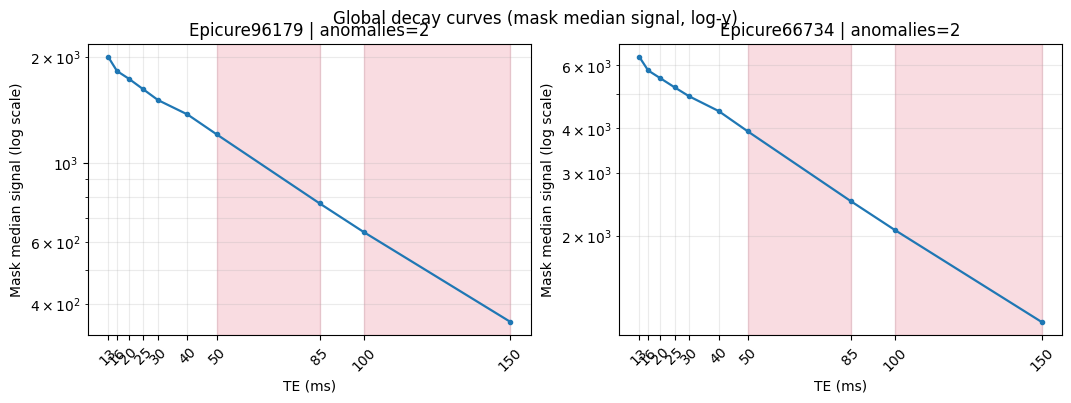

In [61]:
global_profiles = {}
n_cases = len(cases)
n_cols = min(3, max(1, n_cases))
n_rows = (n_cases + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.3 * n_cols, 3.8 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, cp in zip(axes, cases):
    c = case_data[cp.case_id]
    profile = compute_global_decay_profile(
        c['data'],
        c['mask'],
        c['tes'],
        z_thresh=THRESHOLDS['echo_z_thresh'],
        eps=THRESHOLDS['eps'],
    )
    global_profiles[cp.case_id] = profile

    te = c['tes']
    med = profile['median_curve']

    valid = med > 0
    ax.plot(te[valid], med[valid], marker='o', ms=3, lw=1.6)

    for idx in profile['anomaly_indices']:
        ax.axvspan(te[idx], te[idx + 1], color='crimson', alpha=0.15)

    ax.set_yscale('log')
    ax.set_title(f"{cp.case_id} | anomalies={len(profile['anomaly_indices'])}")
    ax.set_xlabel('TE (ms)')
    ax.set_ylabel('Mask median signal (log scale)')
    ax.set_xticks(te[valid])
    ax.set_xticklabels([f'{t:.0f}' for t in te[valid]], rotation=45)
    ax.grid(alpha=0.25, which='both')

for ax in axes[n_cases:]:
    ax.axis('off')

fig.suptitle('Global decay curves (mask median signal, log-y)', y=1.02)
fig.savefig(OUTPUT_DIR / 'global_decay_curves.png', dpi=180)
plt.show()




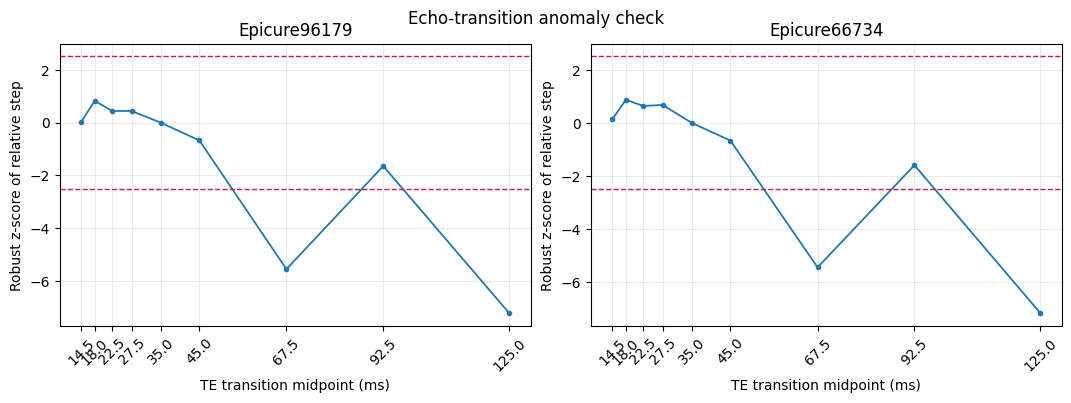

In [62]:
n_cases = len(cases)
n_cols = min(3, max(1, n_cases))
n_rows = (n_cases + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.3 * n_cols, 3.8 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, cp in zip(axes, cases):
    c = case_data[cp.case_id]
    p = global_profiles[cp.case_id]
    te_mid = 0.5 * (c['tes'][:-1] + c['tes'][1:])

    ax.plot(te_mid, p['step_z_scores'], marker='o', ms=3, lw=1.3)
    ax.axhline(THRESHOLDS['echo_z_thresh'], color='crimson', linestyle='--', lw=1)
    ax.axhline(-THRESHOLDS['echo_z_thresh'], color='crimson', linestyle='--', lw=1)
    ax.set_title(cp.case_id)
    ax.set_xlabel('TE transition midpoint (ms)')
    ax.set_ylabel('Robust z-score of relative step')
    ax.set_xticks(te_mid)
    ax.set_xticklabels([f'{t:.1f}' for t in te_mid], rotation=45)
    ax.grid(alpha=0.25)

for ax in axes[n_cases:]:
    ax.axis('off')

fig.suptitle('Echo-transition anomaly check', y=1.02)
fig.savefig(OUTPUT_DIR / 'echo_transition_zscores.png', dpi=180)
plt.show()




## 3) Voxel/ROI Curves

We sample curves from fixed `par_lobe` channels **1, 2, 3** (if present in each case), then plot:
- raw signal vs TE,
- log(signal) vs TE.


In [63]:
curve_frames = []
selected_labels = {}
target_channels = [1, 2, 3]

for cp in cases:
    c = case_data[cp.case_id]
    roi_map = c['par_lobe']
    if roi_map is None:
        selected_labels[cp.case_id] = []
        continue

    available_labels = np.unique(roi_map[c['mask'] > 0]).astype(int).tolist()
    labels = [ch for ch in target_channels if ch in available_labels]
    selected_labels[cp.case_id] = labels

    if not labels:
        continue

    sampled = sample_curves(
        c['data'],
        c['mask'],
        roi_map,
        n_per_roi=30,
        seed=SEED,
        tes=c['tes'],
        roi_labels=labels,
    )
    sampled['case_id'] = cp.case_id
    curve_frames.append(sampled)

curves_df = pd.concat(curve_frames, ignore_index=True) if curve_frames else pd.DataFrame()

display(
    pd.DataFrame(
        {
            'case_id': [cp.case_id for cp in cases],
            'roi_labels': [selected_labels.get(cp.case_id, []) for cp in cases],
            'sample_rows': [
                int((curves_df['case_id'] == cp.case_id).sum()) if not curves_df.empty else 0
                for cp in cases
            ],
        }
    )
)


,case_id,roi_labels,sample_rows
0,Epicure96179,"[1, 2, 3]",880
1,Epicure66734,"[1, 2, 3]",750


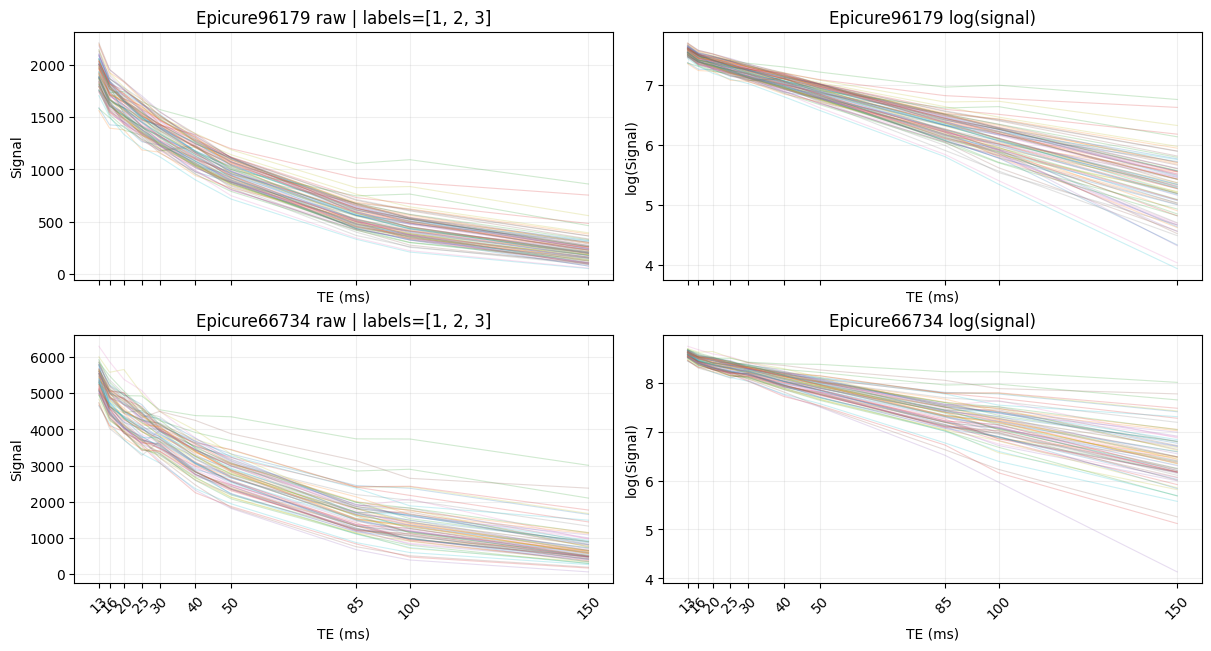

In [64]:
if curves_df.empty:
    raise RuntimeError('No ROI curves sampled. Check ROI maps and masks.')

n_cases = len(cases)
fig, axes = plt.subplots(n_cases, 2, figsize=(12, 3.2 * n_cases), constrained_layout=True, sharex='col')
if n_cases == 1:
    axes = np.array([axes])

for row, cp in enumerate(cases):
    case_id = cp.case_id
    sub = curves_df[curves_df['case_id'] == case_id]
    ax_raw, ax_log = axes[row, 0], axes[row, 1]

    if sub.empty:
        ax_raw.set_visible(False)
        ax_log.set_visible(False)
        continue

    for (_, _), grp in sub.groupby(['roi_label', 'roi_voxel_id']):
        ax_raw.plot(grp['te_ms'], grp['signal'], alpha=0.22, lw=0.8)
        ax_log.plot(grp['te_ms'], grp['log_signal'], alpha=0.22, lw=0.8)

    te_ticks = np.sort(sub['te_ms'].unique())

    ax_raw.set_title(f"{case_id} raw | labels={selected_labels.get(case_id, [])}")
    ax_log.set_title(f"{case_id} log(signal)")
    ax_raw.set_ylabel('Signal')
    ax_log.set_ylabel('log(Signal)')
    ax_raw.set_xlabel('TE (ms)')
    ax_log.set_xlabel('TE (ms)')
    ax_raw.set_xticks(te_ticks)
    ax_log.set_xticks(te_ticks)
    ax_raw.set_xticklabels([f'{t:.0f}' for t in te_ticks], rotation=45)
    ax_log.set_xticklabels([f'{t:.0f}' for t in te_ticks], rotation=45)
    ax_raw.grid(alpha=0.2)
    ax_log.grid(alpha=0.2)
fig.savefig(OUTPUT_DIR / 'sampled_roi_curves.png', dpi=180)
plt.show()




## 4) Assumption Metrics Summary

Per case metrics:
1. Monotonicity violation rate (`?S/S_prev > 5%`)
2. Early-echo monotonicity violation rate
3. Mono-exponential fit quality (`R^2` distribution)
4. Non-positive signal voxel rate
5. Echo-level anomaly count and transitions


In [65]:
metrics_rows = []
for cp in cases:
    c = case_data[cp.case_id]
    m = compute_qc_metrics(c['data'], c['mask'], c['tes'], thresholds=THRESHOLDS, seed=SEED)
    m['case_id'] = cp.case_id
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).sort_values('case_id').reset_index(drop=True)

summary_cols = [
    'case_id',
    'brain_voxels',
    'te_count',
    'te_duplicate_count',
    'mono_violation_rate_pct',
    'early_mono_violation_rate_pct',
    'r2_median',
    'r2_poor_rate_pct',
    'nonpositive_voxel_rate_pct',
    'echo_anomaly_count',
    'echo_anomaly_transitions',
]

metrics_df[summary_cols]


,case_id,brain_voxels,te_count,te_duplicate_count,mono_violation_rate_pct,early_mono_violation_rate_pct,r2_median,r2_poor_rate_pct,nonpositive_voxel_rate_pct,echo_anomaly_count,echo_anomaly_transitions
0,Epicure66734,74869,10,0,32.276376,17.819124,0.990829,32.0,0.822770,2,"50->85ms (-36.2%, z=-5.45); 100->150ms (-44.7%..."
1,Epicure96179,72172,10,0,23.640747,9.981710,0.992592,25.8,1.066896,2,"50->85ms (-36.2%, z=-5.55); 100->150ms (-44.3%..."


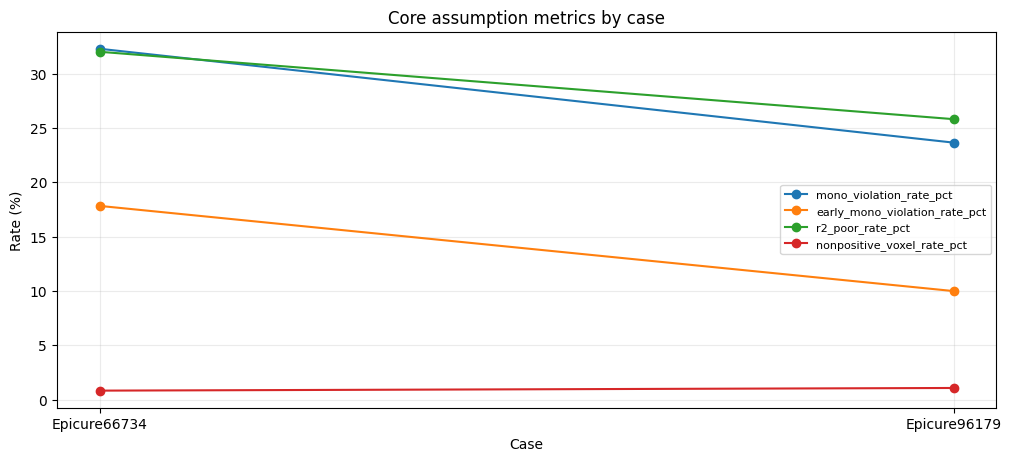

In [66]:
metrics_df.to_csv(OUTPUT_DIR / 'qc_metrics_summary.csv', index=False)

plot_cols = ['mono_violation_rate_pct', 'early_mono_violation_rate_pct', 'r2_poor_rate_pct', 'nonpositive_voxel_rate_pct']
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for col in plot_cols:
    ax.plot(metrics_df['case_id'], metrics_df[col], marker='o', lw=1.5, label=col)
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Case')
ax.set_title('Core assumption metrics by case')
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.savefig(OUTPUT_DIR / 'assumption_metrics_overview.png', dpi=180)
plt.show()


## 5) Distortion Interpretation

Map metrics to likely distortion factors and expected impact on downstream T2/S0 fitting.


In [67]:
reports = []
for _, row in metrics_df.iterrows():
    case_id = row['case_id']
    case_curves = curves_df[curves_df['case_id'] == case_id] if not curves_df.empty else None
    report = make_case_report(
        row.to_dict(),
        case_curves,
        figs={
            'global_decay': 'global_decay_curves.png',
            'echo_zscores': 'echo_transition_zscores.png',
            'roi_curves': 'sampled_roi_curves.png',
        },
    )
    reports.append(report)

report_rows = []
for r in reports:
    report_rows.append(
        {
            'case_id': r['case_id'],
            'risk_score': r['risk_score'],
            'risk_level': r['risk_level'],
            'key_distortion': r['key_distortions'][0],
            'fit_impact': r['fit_impacts'][0],
            'recommendation': r['recommendations'][0],
        }
    )

report_df = pd.DataFrame(report_rows).sort_values(['risk_score', 'case_id'], ascending=[False, True]).reset_index(drop=True)
display(report_df)


,case_id,risk_score,risk_level,key_distortion,fit_impact,recommendation
0,Epicure66734,0.340842,medium,Substantial mono-exponential misfit.,"Single-compartment T2 may be biased, especiall...",Prefer weighted/robust fitting and compare aga...
1,Epicure96179,0.302070,low,Substantial mono-exponential misfit.,"Single-compartment T2 may be biased, especiall...",Prefer weighted/robust fitting and compare aga...


In [68]:
for r in reports:
    print(f"{r['case_id']} | risk={r['risk_level']} ({r['risk_score']:.3f})")
    print('  Distortions:')
    for d in r['key_distortions']:
        print('   -', d)
    print('  Expected fit impact:')
    for d in r['fit_impacts']:
        print('   -', d)
    print('  Recommendations:')
    for d in r['recommendations']:
        print('   -', d)


Epicure66734 | risk=medium (0.341)
  Distortions:
   - Substantial mono-exponential misfit.
   - Non-positive signal in masked voxels.
   - Echo-specific global anomalies.
  Expected fit impact:
   - Single-compartment T2 may be biased, especially in mixed tissue voxels.
   - Log-linear transforms become unstable and can underestimate late-TE signal.
   - May indicate acquisition instability affecting specific TEs.
  Recommendations:
   - Prefer weighted/robust fitting and compare against multi-compartment models.
   - Apply positivity handling (epsilon floor or robust nonlinear fit).
   - Evaluate excluding anomalous echoes in sensitivity analyses.
Epicure96179 | risk=low (0.302)
  Distortions:
   - Substantial mono-exponential misfit.
   - Non-positive signal in masked voxels.
   - Echo-specific global anomalies.
  Expected fit impact:
   - Single-compartment T2 may be biased, especially in mixed tissue voxels.
   - Log-linear transforms become unstable and can underestimate late-TE 

## 6) Risk Ranking + Report-Ready Conclusion


In [69]:
ranking_df = summarize_case_reports(reports)
display(ranking_df)

ranking_df.to_csv(OUTPUT_DIR / 'case_risk_ranking.csv', index=False)
report_df.to_csv(OUTPUT_DIR / 'case_reports_table.csv', index=False)

high_cases = ranking_df.loc[ranking_df['risk_level'] == 'high', 'case_id'].tolist()
dup_cases = metrics_df.loc[metrics_df['te_duplicate_count'] > 0, 'case_id'].tolist()
worst_early = (
    metrics_df.sort_values('early_mono_violation_rate_pct', ascending=False)
    .head(2)['case_id']
    .tolist()
)

conclusion = (
    'Core task 1 conclusion: data quality differs across subjects. '
    f"Highest QC risk cases are {', '.join(high_cases) if high_cases else 'none'}. "
    f"Duplicate echo metadata was detected in {', '.join(dup_cases) if dup_cases else 'none'} (notably case02). "
    f"Strongest early-echo monotonicity violations were seen in {', '.join(worst_early)}. "
    'These effects can bias one-compartment T2/S0 estimation; downstream fitting should include '
    'echo-sensitivity analysis, robust/weighted fitting, and per-case QC-aware preprocessing.'
)

display(Markdown('**Conclusion paragraph (for coursework report):**'))
print(conclusion)

(OUTPUT_DIR / 'core_task1_conclusion.txt').write_text(conclusion, encoding='utf-8')


,case_id,risk_score,risk_level,top_distortion,top_recommendation
0,Epicure66734,0.340842,medium,Substantial mono-exponential misfit.,Prefer weighted/robust fitting and compare aga...
1,Epicure96179,0.302070,low,Substantial mono-exponential misfit.,Prefer weighted/robust fitting and compare aga...


**Conclusion paragraph (for coursework report):**

Core task 1 conclusion: data quality differs across subjects. Highest QC risk cases are none. Duplicate echo metadata was detected in none (notably case02). Strongest early-echo monotonicity violations were seen in Epicure66734, Epicure96179. These effects can bias one-compartment T2/S0 estimation; downstream fitting should include echo-sensitivity analysis, robust/weighted fitting, and per-case QC-aware preprocessing.


422

## 7) Synthetic Sanity Tests

Checks that QC metrics react in the expected direction on controlled synthetic data.


In [70]:
synthetic = run_synthetic_sanity_checks(seed=SEED, verbose=False)
synthetic_df = pd.DataFrame(
    [
        {
            'scenario': key,
            'mono_violation_rate_pct': value['mono_violation_rate_pct'],
            'early_mono_violation_rate_pct': value['early_mono_violation_rate_pct'],
            'r2_median': value['r2_median'],
            'r2_poor_rate_pct': value['r2_poor_rate_pct'],
            'te_duplicate_count': value['te_duplicate_count'],
        }
        for key, value in synthetic.items()
    ]
)
display(synthetic_df)
print('Synthetic sanity checks passed.')


,scenario,mono_violation_rate_pct,early_mono_violation_rate_pct,r2_median,r2_poor_rate_pct,te_duplicate_count
0,baseline,20.833333,0.000000,0.996961,0.000000,0
1,anomalous,76.000000,33.333333,0.985147,0.166667,0
2,anomalous_dup_te,76.000000,33.333333,0.984970,0.166667,1


Synthetic sanity checks passed.


## Deliverables Produced by This Notebook

Saved under `core_task1/outputs/`:
- `global_decay_curves.png`
- `echo_transition_zscores.png`
- `sampled_roi_curves.png`
- `assumption_metrics_overview.png`
- `qc_metrics_summary.csv`
- `case_risk_ranking.csv`
- `case_reports_table.csv`
- `core_task1_conclusion.txt`
